In [16]:
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

logit_valid = pd.read_csv("data/processed/logit_valid_predictions.csv")
logit_test = pd.read_csv("data/processed/logit_test_predictions.csv")

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
df_model = pd.read_csv("data/processed/accepted_model_base.csv")
print(df_model.shape)
df_model.head()

(1371166, 25)


,loan_amnt,term,installment,grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,purpose,...,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,fico_avg,credit_history_years,loan_status,target_bad
0,3600.0,36.0,123.03,C,10+ years,MORTGAGE,55000.0,Not Verified,2015-12-01,debt_consolidation,...,0.0,2765.0,29.7,13.0,1.0,0.0,677.0,12.334018,Fully Paid,0
1,24700.0,36.0,820.28,C,10+ years,MORTGAGE,65000.0,Not Verified,2015-12-01,small_business,...,0.0,21470.0,19.2,38.0,4.0,0.0,717.0,16.000000,Fully Paid,0
2,20000.0,60.0,432.66,B,10+ years,MORTGAGE,63000.0,Not Verified,2015-12-01,home_improvement,...,0.0,7869.0,56.2,18.0,5.0,0.0,697.0,15.331964,Fully Paid,0
3,10400.0,60.0,289.91,F,3 years,MORTGAGE,104433.0,Source Verified,2015-12-01,major_purchase,...,0.0,21929.0,64.5,35.0,6.0,0.0,697.0,17.500342,Fully Paid,0
4,11950.0,36.0,405.18,C,4 years,RENT,34000.0,Source Verified,2015-12-01,debt_consolidation,...,0.0,8822.0,68.4,6.0,0.0,0.0,692.0,28.167009,Fully Paid,0


In [18]:
train_df = df_model[df_model["issue_d"] < "2016-01-01"].copy()
valid_df = df_model[(df_model["issue_d"] >= "2016-01-01") & (df_model["issue_d"] < "2017-01-01")].copy()
test_df = df_model[df_model["issue_d"] >= "2017-01-01"].copy()

print(train_df.shape, valid_df.shape, test_df.shape)

(828654, 25) (298553, 25) (243959, 25)


In [19]:
drop_cols = ["loan_status", "target_bad", "issue_d"]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df["target_bad"]

X_valid = valid_df.drop(columns=drop_cols)
y_valid = valid_df["target_bad"]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df["target_bad"]

In [20]:
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols),
])

Numeric columns: ['loan_amnt', 'term', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'fico_avg', 'credit_history_years']
Categorical columns: ['grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'addr_state']


In [21]:
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.pipeline import Pipeline

tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=2000,
        random_state=42
    ))
])

tree_model.fit(X_train, y_train)

valid_pred_tree = tree_model.predict_proba(X_valid)[:, 1]
test_pred_tree = tree_model.predict_proba(X_test)[:, 1]

print("Validation ROC AUC:", roc_auc_score(y_valid, valid_pred_tree))
print("Validation PR AUC:", average_precision_score(y_valid, valid_pred_tree))
print("Test ROC AUC:", roc_auc_score(y_test, valid_pred_tree if False else test_pred_tree))
print("Test PR AUC:", average_precision_score(y_test, test_pred_tree))

Validation ROC AUC: 0.6803352429361342
Validation PR AUC: 0.38186642549548266
Test ROC AUC: 0.66378293333119
Test PR AUC: 0.39140523378965164


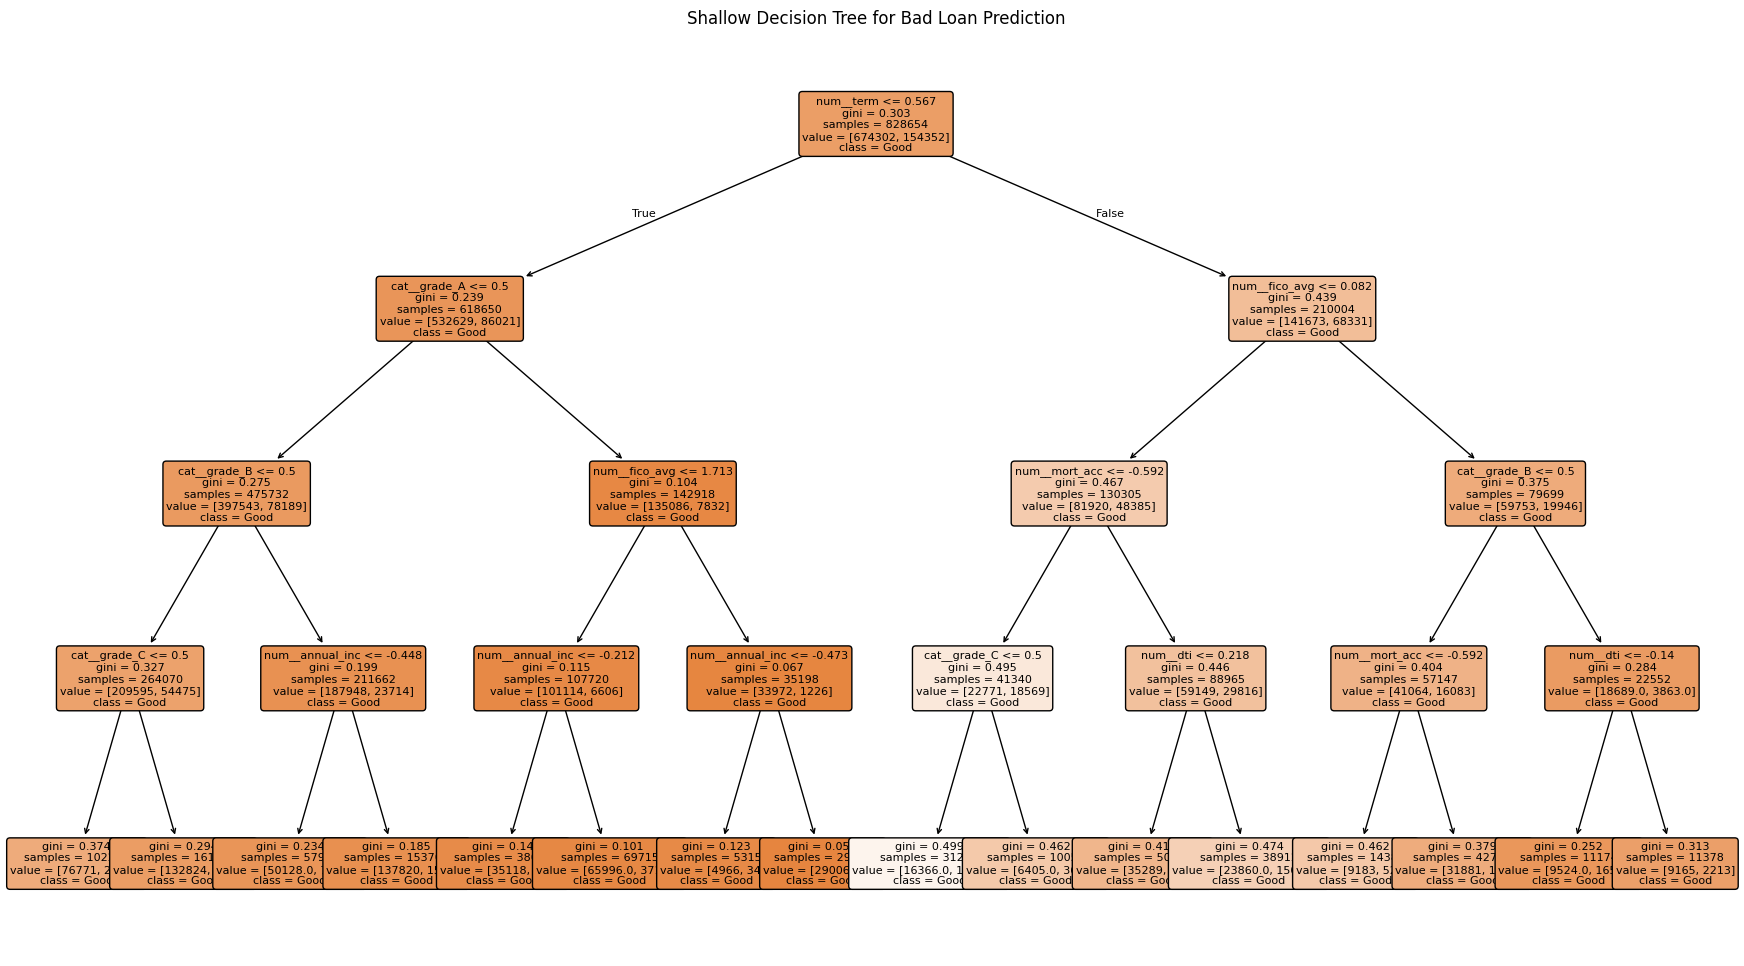

In [22]:
fitted_preprocessor = tree_model.named_steps["preprocessor"]
fitted_tree = tree_model.named_steps["classifier"]

feature_names = fitted_preprocessor.get_feature_names_out()

plt.figure(figsize=(22, 12))
plot_tree(
    fitted_tree,
    feature_names=feature_names,
    class_names=["Good", "Bad"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Shallow Decision Tree for Bad Loan Prediction")
plt.show()

**Note: The below RandomForest will take ~7.5 minutes. So use sparingly.**

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.pipeline import Pipeline

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

valid_pred_rf = rf_model.predict_proba(X_valid)[:, 1]
test_pred_rf = rf_model.predict_proba(X_test)[:, 1]

print("Validation ROC AUC:", roc_auc_score(y_valid, valid_pred_rf))
print("Validation PR AUC:", average_precision_score(y_valid, valid_pred_rf))
print("Test ROC AUC:", roc_auc_score(y_test, test_pred_rf))
print("Test PR AUC:", average_precision_score(y_test, test_pred_rf))

Validation ROC AUC: 0.7093513976244067
Validation PR AUC: 0.4357093917533329
Test ROC AUC: 0.6967097587279377
Test PR AUC: 0.44040019250922946


In [13]:
results = pd.DataFrame({
    "model": ["logistic_regression", "decision_tree_depth4", "random_forest"],
    "valid_roc_auc": [
        roc_auc_score(logit_valid["y_valid"], logit_valid["pred_logit"]),
        roc_auc_score(y_valid, valid_pred_tree),
        roc_auc_score(y_valid, valid_pred_rf),
    ],
    "valid_pr_auc": [
        average_precision_score(logit_valid["y_valid"], logit_valid["pred_logit"]),
        average_precision_score(y_valid, valid_pred_tree),
        average_precision_score(y_valid, valid_pred_rf),
    ],
    "test_roc_auc": [
        roc_auc_score(logit_test["y_test"], logit_test["pred_logit"]),
        roc_auc_score(y_test, test_pred_tree),
        roc_auc_score(y_test, test_pred_rf),
    ],
    "test_pr_auc": [
        average_precision_score(logit_test["y_test"], logit_test["pred_logit"]),
        average_precision_score(y_test, test_pred_tree),
        average_precision_score(y_test, test_pred_rf),
    ],
})

results

,model,valid_roc_auc,valid_pr_auc,test_roc_auc,test_pr_auc
0,logistic_regression,0.707338,0.433477,0.693261,0.433680
1,decision_tree_depth4,0.680335,0.381866,0.663783,0.391405
2,random_forest,0.709351,0.435709,0.696710,0.440400


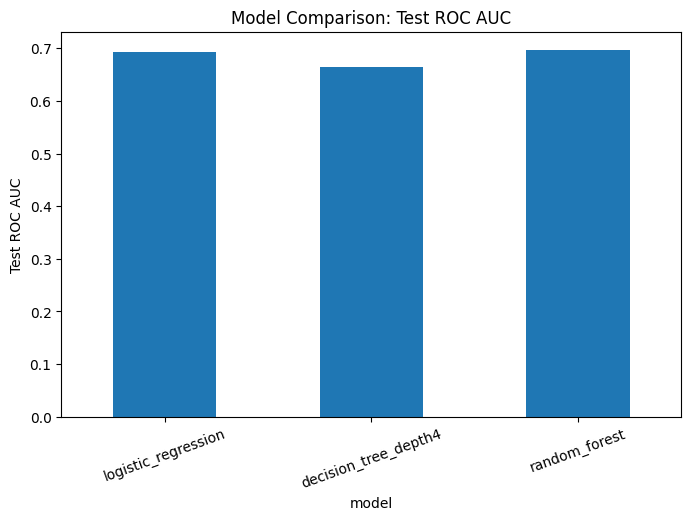

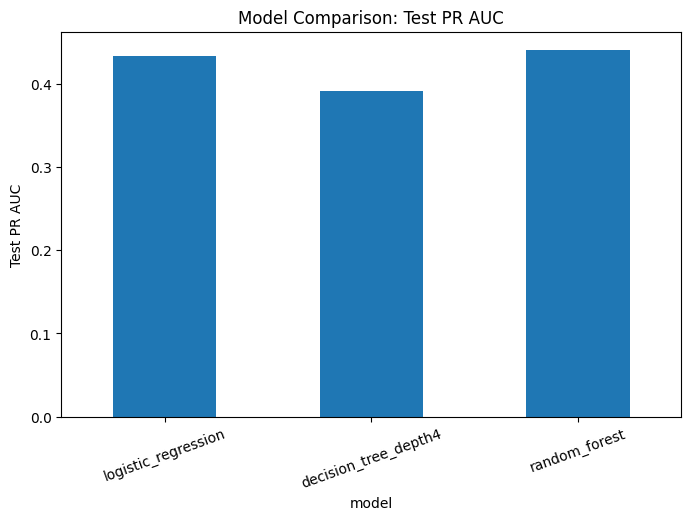

In [14]:
import matplotlib.pyplot as plt

plot_df = results.set_index("model")

plt.figure(figsize=(8, 5))
plot_df["test_roc_auc"].plot(kind="bar")
plt.ylabel("Test ROC AUC")
plt.title("Model Comparison: Test ROC AUC")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(8, 5))
plot_df["test_pr_auc"].plot(kind="bar")
plt.ylabel("Test PR AUC")
plt.title("Model Comparison: Test PR AUC")
plt.xticks(rotation=20)
plt.show()

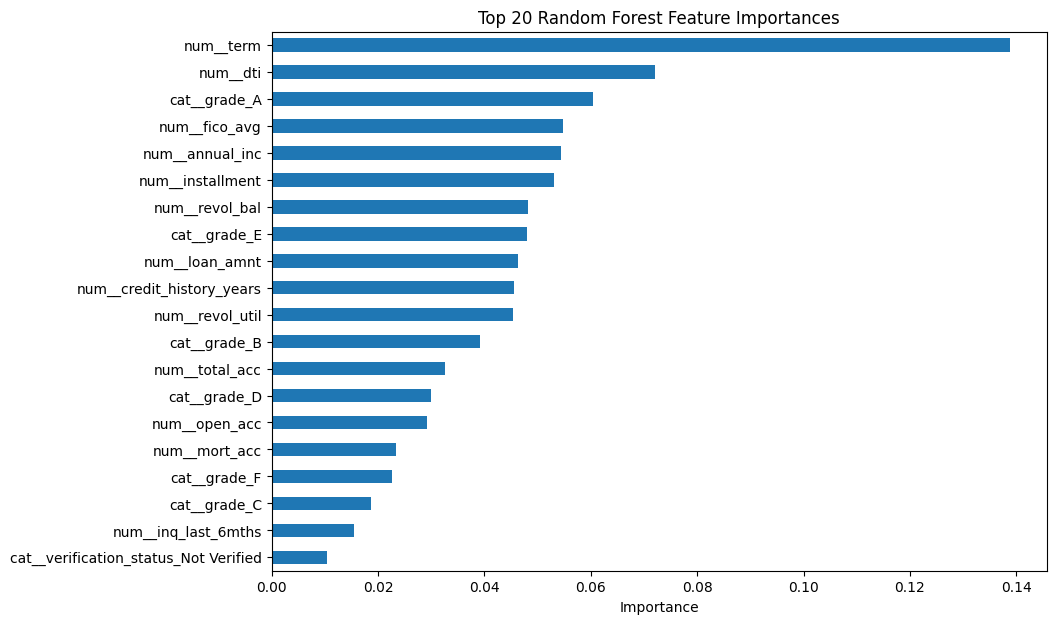

In [15]:
rf_classifier = rf_model.named_steps["classifier"]
rf_preprocessor = rf_model.named_steps["preprocessor"]
rf_feature_names = rf_preprocessor.get_feature_names_out()

importances = pd.Series(
    rf_classifier.feature_importances_,
    index=rf_feature_names
).sort_values(ascending=False)

top_importances = importances.head(20)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
top_importances.sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Top 20 Random Forest Feature Importances")
plt.show()